In [1]:
# importing packages
from segmentation import multi_unet_model

from keras.utils import normalize
import os
from glob import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
import shutil

In [2]:
# image size
SIZE_X = 512
SIZE_Y = 512
n_classes = 2  # class 1 is background, class 2 is hair

In [3]:
# load images from directory as greyscale
# resize images and save them as array
#
train_images = list()
for path in glob("data/images/*"):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (SIZE_Y,SIZE_X))
    train_images.append(img)
train_images = np.array(train_images)

In [4]:
# load masks from directory as greyscale
# resize masks and save them as array
#
train_masks = list()
for path in glob("data/masks/*"):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (SIZE_Y,SIZE_X), interpolation = cv2.INTER_NEAREST)
    train_masks.append(img)
train_masks = np.array(train_masks)

In [5]:
#size of train images
train_images.shape

(131, 512, 512)

In [6]:
# converting all mask pixels other than 0 to 1
for e,mask in enumerate(train_masks):
    train_masks[e][train_masks[e]>0] = 1

In [7]:
# unique pixel value of mask
np.unique(train_masks)

array([0, 1], dtype=uint8)

In [20]:
# adding 3rd dimension for unet model 
# normalizing image with keras normalizer
# it divides each pixel with 255 to change pixel between 0-1
#
train_images = np.expand_dims(train_images, axis=3)
train_images = normalize(train_images, axis=1)

In [21]:
# adding dimension for masks just like true images
train_masks_input = np.expand_dims(train_masks, axis=3)

In [22]:
# splitting data in to train/test. 10% is for testing
x_train, x_test, y_train, y_test = train_test_split(train_images, train_masks_input, test_size=0.1, random_state=0)

In [23]:
# transforming masks from array to pixel one hot encoder as explained in doc
#
train_masks_cat = to_categorical(y_train, num_classes=n_classes)
y_train_cat = train_masks_cat.reshape((y_train.shape[0], y_train.shape[1], y_train.shape[2], n_classes))
train_masks_cat.shape

(117, 512, 512, 2)

In [24]:
# categorizing now test masks
test_masks_cat = to_categorical(y_test, num_classes=n_classes)
y_test_cat = test_masks_cat.reshape((y_test.shape[0], y_test.shape[1], y_test.shape[2], n_classes))
test_masks_cat.shape

(14, 512, 512, 2)

In [25]:
# intialize model with class number, image size and channel number
# train model
#
model = multi_unet_model(n_classes=n_classes, IMG_HEIGHT=SIZE_Y, IMG_WIDTH=SIZE_X, IMG_CHANNELS=1)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train_cat,
         batch_size=2,
          epochs=100,
         verbose=1,
         validation_data=(x_test,y_test_cat))

Epoch 1/100
59/59 [==============================] - 121s 2s/step - loss: 0.1716 - accuracy: 0.9713 - val_loss: 0.1951 - val_accuracy: 0.9633
Epoch 2/100
59/59 [==============================] - 119s 2s/step - loss: 0.1400 - accuracy: 0.9715 - val_loss: 0.1571 - val_accuracy: 0.9633
Epoch 3/100
59/59 [==============================] - 118s 2s/step - loss: 0.1327 - accuracy: 0.9715 - val_loss: 0.1571 - val_accuracy: 0.9633
Epoch 4/100
59/59 [==============================] - 118s 2s/step - loss: 0.1318 - accuracy: 0.9715 - val_loss: 0.1568 - val_accuracy: 0.9633
Epoch 5/100
59/59 [==============================] - 122s 2s/step - loss: 0.1320 - accuracy: 0.9715 - val_loss: 0.1565 - val_accuracy: 0.9633
Epoch 6/100
59/59 [==============================] - 122s 2s/step - loss: 0.1292 - accuracy: 0.9715 - val_loss: 0.1550 - val_accuracy: 0.9633
Epoch 7/100
59/59 [==============================] - 118s 2s/step - loss: 0.1280 - accuracy: 0.9715 - val_loss: 0.1585 - val_accuracy: 0.9633
Epoch 

In [8]:
# save trained model
model.save("unet_512.h5")

NameError: name 'model' is not defined

C:\Users\adils\AppData\Local\Temp/ipykernel_17784/2274746774.py:10: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  f.show()
C:\Users\adils\AppData\Local\Temp/ipykernel_17784/2274746774.py:20: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  f.show()


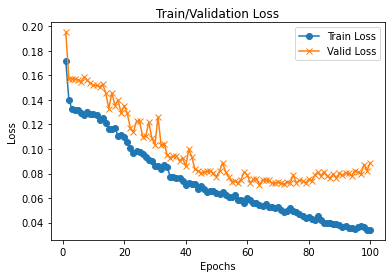

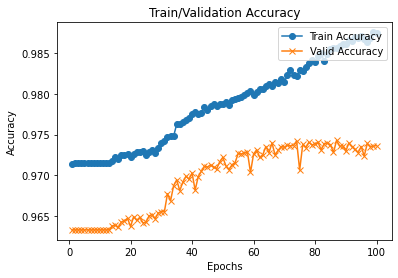

In [27]:
# plotting loss and accuracy 
f, ax = plt.subplots()
ax.plot([None] + model.history.history['loss'], 'o-')
ax.plot([None] + model.history.history['val_loss'], 'x-')

ax.legend(['Train Loss', 'Valid Loss'], loc=1)
ax.set_title('Train/Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
f.show()

f, ax = plt.subplots()
ax.plot([None] + model.history.history['accuracy'], 'o-')
ax.plot([None] + model.history.history['val_accuracy'], 'x-')

ax.legend(['Train Accuracy', 'Valid Accuracy'], loc=1)
ax.set_title('Train/Validation Accuracy')
ax.set_xlabel('Epochs')
ax.set_ylabel('Accuracy')
f.show()

1/1 [==============================] - 0s 307ms/step


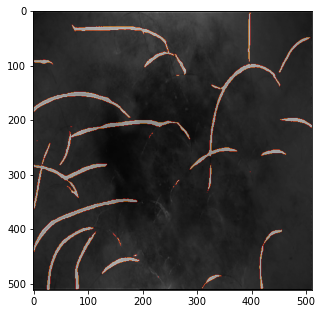

In [48]:
# predicting hair segmentation on any random test image
import random
test_img_number = random.randint(0, len(x_test))
test_img = x_test[test_img_number]
ground_truth=y_test[test_img_number]
test_img_norm=test_img[:,:,0][:,:,None]
test_img_input=np.expand_dims(test_img_norm, 0)
prediction = (model.predict(test_img_input))
predicted_img=np.argmax(prediction, axis=3)[0,:,:]

plt.figure(figsize=(5,6))
plt.imshow(test_img[:,:,0], cmap='gray')
plt.imshow(predicted_img, cmap='gist_heat', alpha=0.5)
plt.show()

In [5]:
import os
from PIL import Image

In [6]:
test_images = os.listdir("data/Test")

In [31]:
# predicting hair of all test images and saving it in Test directory with true images
for image_name in test_images:
    path = "data/Test/" + image_name
    image_rgb = cv2.imread(path)
    image_rgb = cv2.resize(image_rgb, (SIZE_Y,SIZE_X))
    image_rgb = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2RGB)
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (SIZE_Y,SIZE_X))
    img = np.expand_dims(image, axis=[0,3])
    img = normalize(img, axis=1)
    prediction = (model.predict(img))
    predicted_img=np.argmax(prediction, axis=3)[0,:,:]
    plt.imsave('temp.png', image_rgb)
    plt.imsave('temp_mask.png', predicted_img, cmap='gist_heat')
    background = Image.open('temp.png')
    overlay = Image.open('temp_mask.png')
    new_img = Image.blend(background, overlay, 0.5)
    new_img.save('data/Test/'+ image_name.split('.')[0] + '_res.png', "PNG")

1/1 [==============================] - 0s 177ms/step


In [5]:
# training is not required everytime so just directly load saved model from here
# and predict on images
#
from keras.models import load_model
model = load_model("unet_512.h5")

In [6]:
# give image path from directory to this function to segment hair
def segment_hair(image_path):
    image_rgb = cv2.imread(image_path)
    image_rgb = cv2.resize(image_rgb, (SIZE_Y,SIZE_X))
    image_rgb = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2RGB)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (SIZE_Y,SIZE_X))
    img = np.expand_dims(image, axis=[0,3])
    img = normalize(img, axis=1)
    prediction = (model.predict(img))
    predicted_img=np.argmax(prediction, axis=3)[0,:,:]
    return image_rgb, predicted_img

In [7]:
# pass predicted result from this function to count hair
# bold black patches on plotted image are the hair considered
def count_hair(image):
    img = np.uint8(image)
    img[img>=1] = 255
    _, img = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY_INV)
    edged = cv2.Canny(img, 10, 200)
    contours, hierarchy = cv2.findContours(edged, cv2.RETR_EXTERNAL,
                                      cv2.CHAIN_APPROX_NONE)
    count = []
    for x in contours:
        area = cv2.contourArea(x)
        if area > 0 :
            count.append(x)
    img = cv2.drawContours(img, count, -1, (0,0,255), 7)
    edged = cv2.Canny(img, 10, 200)
    contours, hierarchy = cv2.findContours(edged, cv2.RETR_EXTERNAL,
                                          cv2.CHAIN_APPROX_NONE)
    count = []
    for x in contours:
        area = cv2.contourArea(x)
        if area > 0 :
            count.append(x)
    return len(count), img

In [8]:
# pass path of image to plot results
def predict_result(image_path):
    orig_img, segmented_img = segment_hair(image_path)
    hair_count, hair_img = count_hair(segmented_img)

    plt.figure(figsize=(12,8))
    plt.subplot(1,3,1)
    plt.imshow(orig_img)
    plt.title("Input Image")

    plt.subplot(1,3,2)
    plt.imshow(segmented_img,cmap='gray')
    plt.title("Segmented Image")

    plt.subplot(1,3,3)
    plt.imshow(hair_img, cmap='gray')
    plt.title(f"Hair Count: {hair_count}")
    plt.show()

1/1 [==============================] - 1s 935ms/step


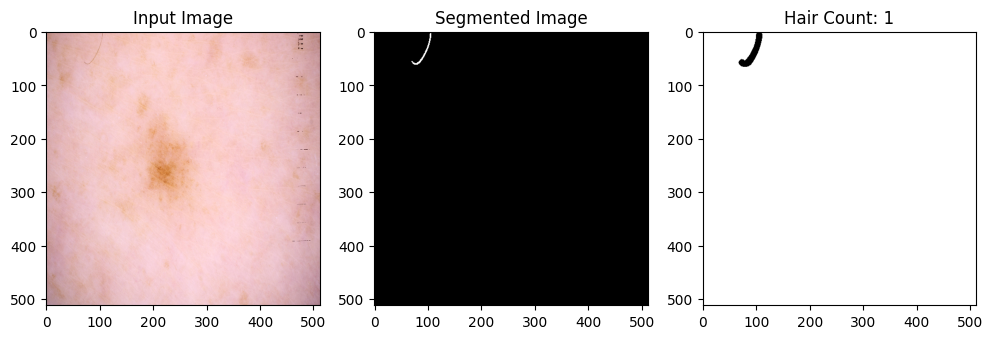

In [9]:
# add path of image and run the function to plot results
image_path = 'data/ISIC_1600890[1].jpg'
predict_result(image_path)

In [19]:
def classify_image(image_path):
    orig_img, segmented_img = segment_hair(image_path)
    hair_count, hair_img = count_hair(segmented_img)
    try:
        os.makedirs(f'Classify/{hair_count}/')
    except:
        pass
    cv2.imwrite(f'Classify/{hair_count}/{image_path.split("/")[-1]}',hair_img)

In [20]:
def classify_folder(folder_path, thresh):
    for image_path in glob(folder_path + "/*"):
        orig_img, segmented_img = segment_hair(image_path)
        hair_count, hair_img = count_hair(segmented_img)
        if hair_count >= thresh:
            try:
                os.makedirs(f'Classify/{thresh}/')
            except:
                pass
            img_name = image_path.split('\\')[-1]
            shutil.copy(image_path, f"Classify/{thresh}/{img_name}")
        else:
            try:
                os.makedirs(f'Classify/{hair_count}/')
            except:
                pass
            img_name = image_path.split('\\')[-1]
            shutil.copy(image_path, f"Classify/{hair_count}/{img_name}")

In [32]:
# classify folder, folder should only contain images
image_folder = 'data/Test images'
classify_folder(image_folder, thresh=20)

1/1 [==============================] - 0s 199ms/step


1/1 [==============================] - 0s 187ms/step


1/1 [==============================] - 0s 172ms/step


1/1 [==============================] - 0s 188ms/step


1/1 [==============================] - 0s 188ms/step


...

1/1 [==============================] - 1s 792ms/step


1/1 [==============================] - 1s 961ms/step


1/1 [==============================] - 1s 1s/step


1/1 [==============================] - 1s 784ms/step


1/1 [==============================] - 1s 689ms/step
